> # **PERCEPTRON**
> A `perceptron` is a basic building block in `deep learning` that works in a somewhat similar way. It’s a `simple type of artificial neuron` used for `binary classification` tasks deciding between two options, like "yes" or "no."
<BR><BR>
> 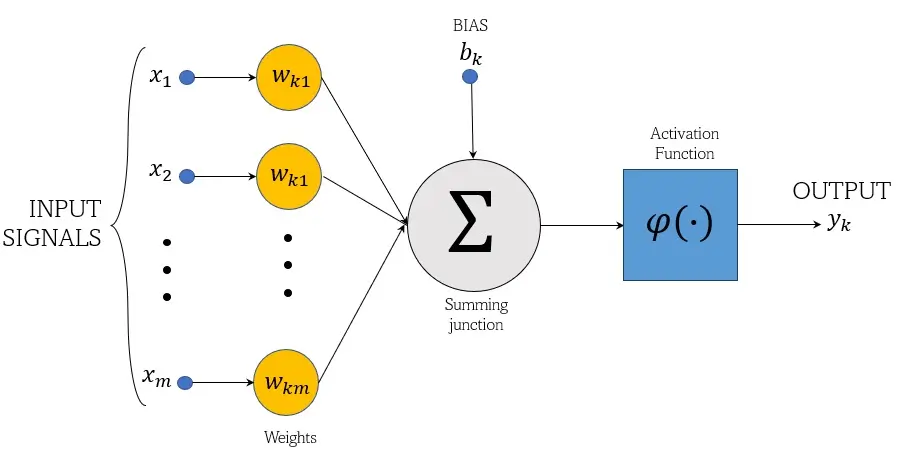

In [103]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.metrics import f1_score

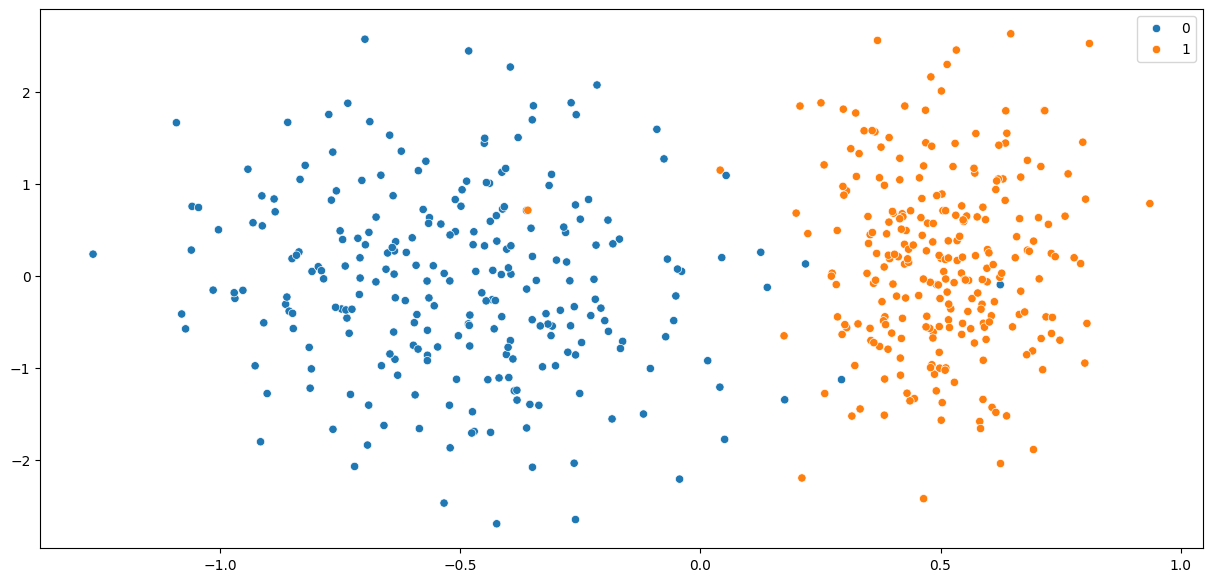

In [104]:
X, y = make_classification(
    n_samples = 500,
    n_features = 2,
    n_informative = 1,
    n_redundant = 0,
    n_classes = 2,
    n_clusters_per_class = 1,
    class_sep = 0.5,
    random_state = 42
)

plt.figure(figsize=(15, 7))
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y)
plt.show()

> ### WORKING OF PERCEPTRON:
> - `Inputs`: It takes in multiple pieces of information, which we call inputs. For our umbrella example, these could be "cloudy" and "rain forecast."
<BR><BR>
> - `Weights`: Each input is associated with a weight, which represents how important that input is. For instance, "rain forecast" might have a higher weight than "cloudy" because it's more crucial in deciding if you need an umbrella.
<BR><BR>
> - `Weighted Sum`: The perceptron multiplies each input by its weight and adds them all up. This is like calculating a total score based on how important each piece of information is.
<BR><BR>
> - `Activation Function`: After calculating the weighted sum, the perceptron uses a function to make a final decision. In its simplest form, this is a step function. If the weighted sum is above a certain threshold, it outputs one option (like "yes" for taking an umbrella). If it’s below, it outputs the other option (like "no").

In [109]:
class Perceptron:
    def __init__(self, lr, epochs):
        self.coef_ = None        # Coefficients for the features (weights)
        self.intercept_ = None   # Intercept term (bias)
        self.lr = lr             # Learning rate for weight updates
        self.epochs = epochs     # Number of iterations for training

    def step(self, fx):
        # Activation function: returns 1 if fx >= 0, otherwise -1
        return 1 if fx >= 0 else -1

    def fit(self, X_train, y_train):
        # Convert y_train to -1 and 1
        y_train = np.where(y_train == 0, -1, y_train)
        
        # Initialize weights (coef_) and intercept (intercept_) to small random values
        self.coef_ = np.random.randn(X_train.shape[1])
        self.intercept_ = 0

        # Gradient Descent algorithm
        for _ in range(self.epochs):
            for idx in np.random.permutation(X_train.shape[0]):
                # Calculate predicted value (y_hat) for each training example
                y_hat = self.step(np.dot(X_train[idx], self.coef_) + self.intercept_)
                
                # Update the weights and intercept if there is a misclassification
                if y_hat != y_train[idx]:
                    self.coef_ += self.lr * y_train[idx] * X_train[idx]
                    self.intercept_ += self.lr * y_train[idx]

    def predict(self, X_test):
        # Calculate the weighted sum for each test example
        ans = np.dot(X_test, self.coef_) + self.intercept_
        # Apply the step function to determine the class label
        return np.where(ans >= 0, 1, 0)

In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [120]:
model = Perceptron(0.01, 100)
model.fit(X_train, y_train)

print(model.intercept_)
print(model.coef_)

-0.08999999999999997
[0.58523955 0.03926158]


In [121]:
f1_score(y_test, model.predict(X_test))

1.0

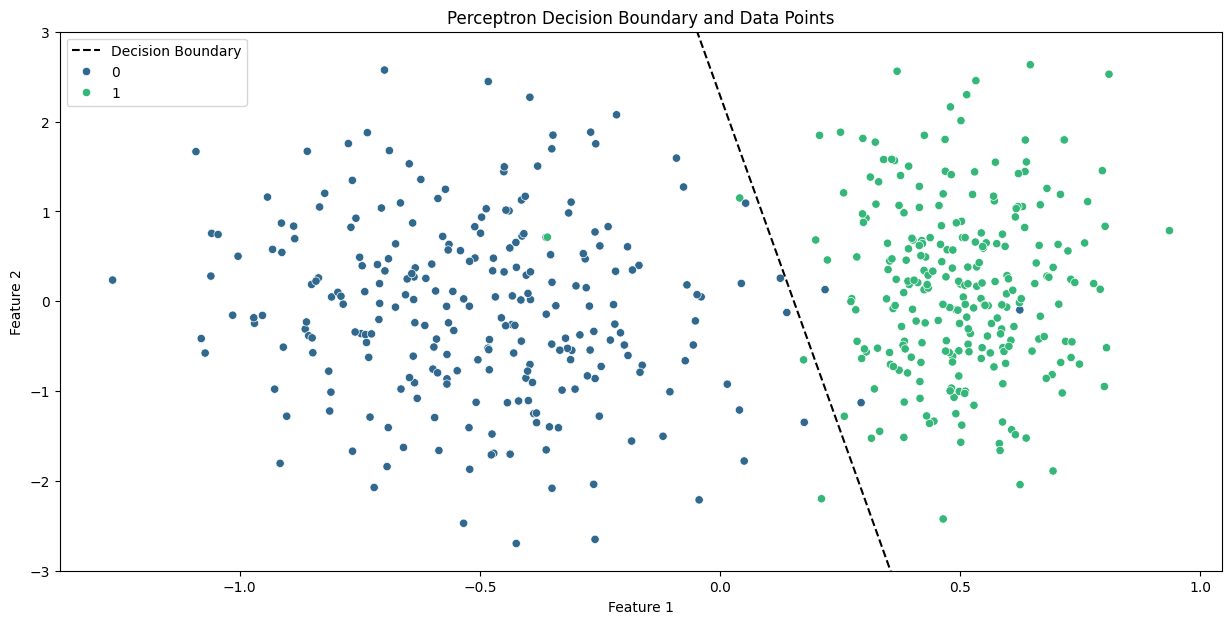

In [122]:
# Assuming X is your feature matrix and y is the target array
# Calculate the decision boundary
weight = -model.coef_[0] / model.coef_[1]
bias = -model.intercept_ / model.coef_[1]

# Create a range of values for the decision boundary plot
temp_x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# Decision boundary equation
temp_x2 = weight * temp_x1 + bias

# Plot the decision boundary
plt.figure(figsize=(15, 7))

# Plot decision boundary
plt.plot(temp_x1, temp_x2, 'k--', label='Decision Boundary')

# Plot the data points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full')

# Label the axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary and Data Points')

# Add a legend and show the plot
plt.ylim(-3, 3)
plt.legend()
plt.show()